In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: nsreennashaat
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset


100%|██████████| 2.70G/2.70G [02:35<00:00, 18.7MB/s]


# Plant Health Detection Project
## 1. Import

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix

# Phase 1: Data Collection, Exploration, and Preprocessing
## 2. Data Preprocessing
## Loading Traning Set

In [4]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/content/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


Found 70295 files belonging to 38 classes.


## Loading Validation Set

In [5]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/content/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


Found 17572 files belonging to 38 classes.


## Exploratory Data Analysis (EDA)
### 1. Analyze Class Distribution

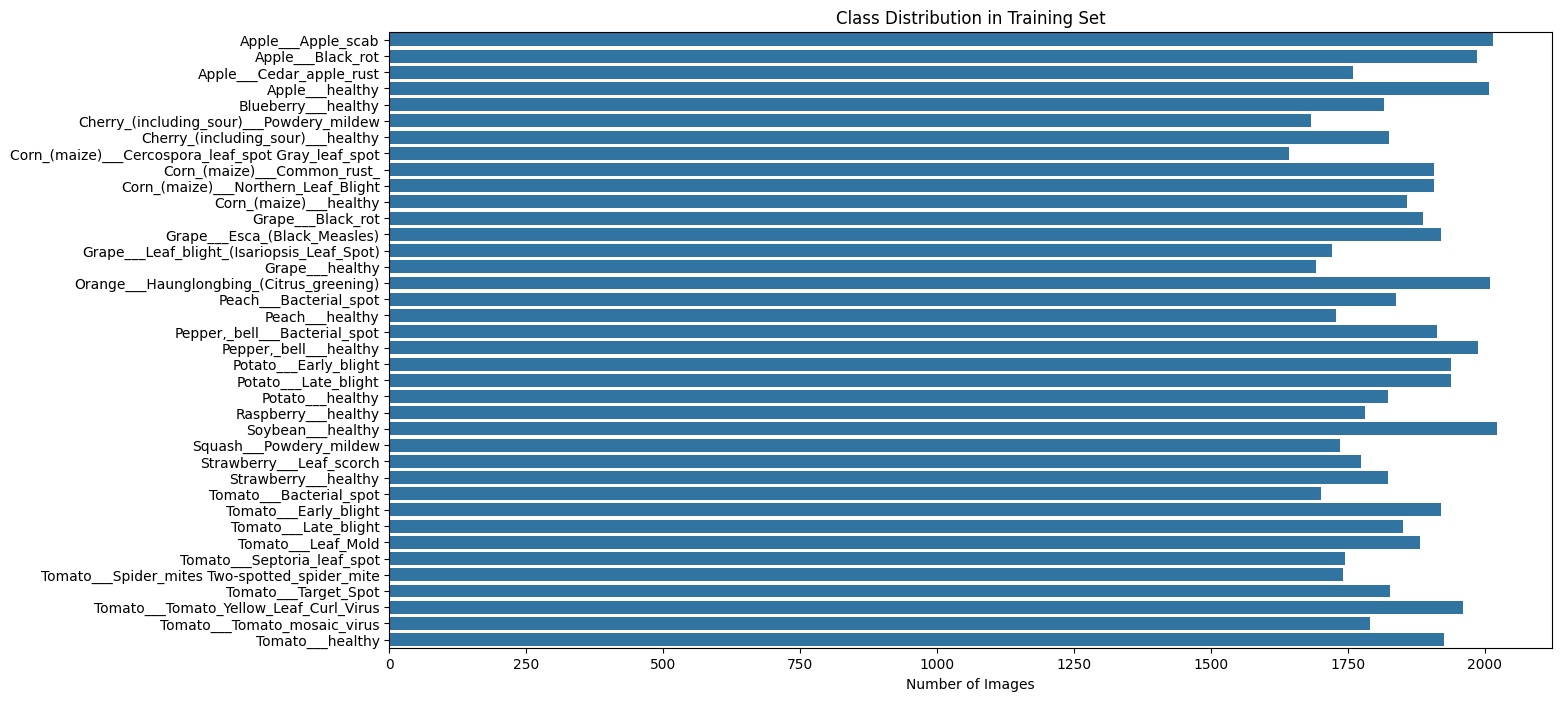

In [6]:
# Extract class names
class_names = training_set.class_names

# Count images per class (assuming your folder structure is standard)
train_dir = '/content/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
counts = {folder: len(os.listdir(os.path.join(train_dir, folder))) for folder in class_names}

# Plotting
plt.figure(figsize=(15, 8))
sns.barplot(x=list(counts.values()), y=list(counts.keys()))
plt.title("Class Distribution in Training Set")
plt.xlabel("Number of Images")
plt.show()

### 2. Visualize Sample Images

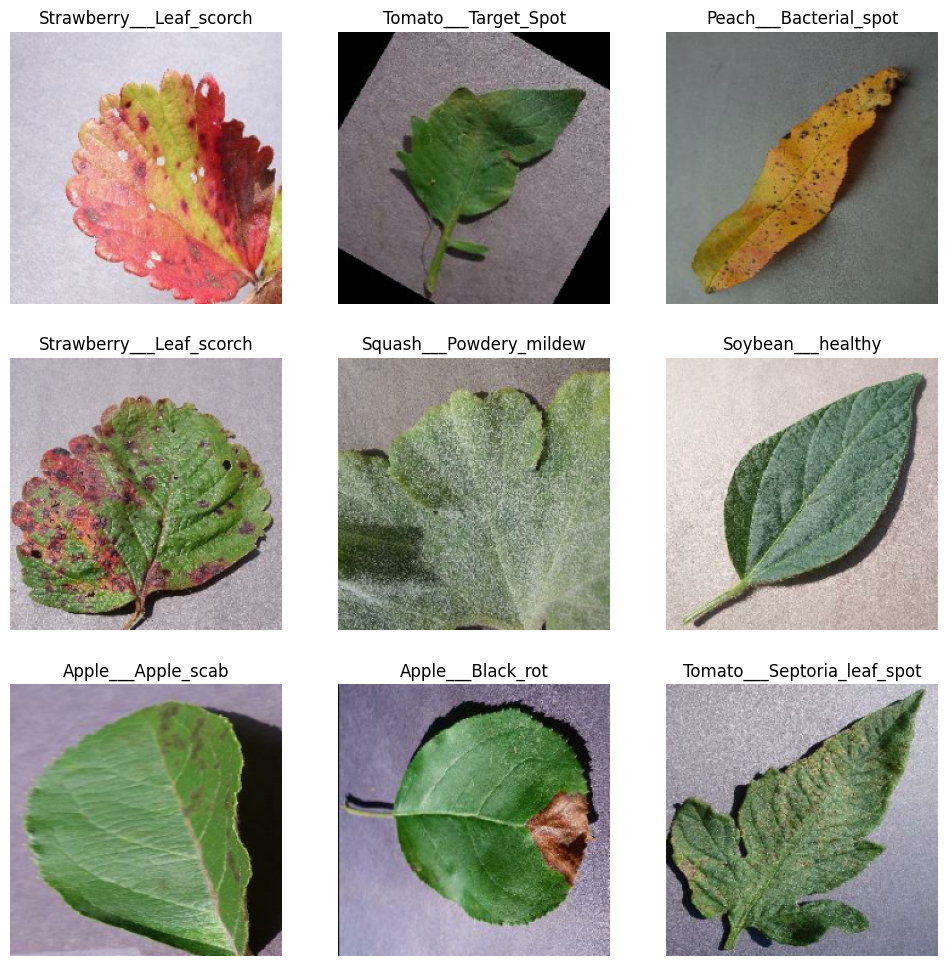

In [7]:
plt.figure(figsize=(12, 12))
for images, labels in training_set.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        # Since labels are categorical, we find the index of the '1'
        label_idx = tf.argmax(labels[i]).numpy()
        plt.title(class_names[label_idx])
        plt.axis("off")

In [8]:
def plot_color_histogram(image, title):
    colors = ('red', 'green', 'blue')
    plt.figure(figsize=(8, 4))
    img_array = image.numpy()
    for i, col in enumerate(colors):
        channel_values = img_array[:, :, i].flatten()
        plt.hist(channel_values, bins=256, color=col, alpha=0.5, label=col)

    plt.title(f"Color Distribution: {title}")
    plt.legend()
    plt.show()

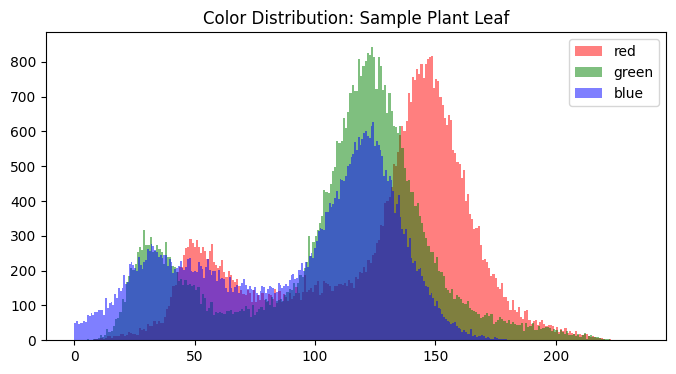

In [9]:
for images, labels in training_set.take(1):
    sample_image = images[0]

    plot_color_histogram(sample_image, "Sample Plant Leaf")

### 3. Normalization

In [10]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
training_set = training_set.map(lambda x, y: (normalization_layer(x), y))
validation_set = validation_set.map(lambda x, y: (normalization_layer(x), y))

### 4. Data Augmentation

In [11]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.1),
])

# Phase 2: Advanced Data Analysis and Model Selection
## 1. Excess Green Index (ExG)
### Excess Green Index helps isolate the "greenness" of the leaf by subtracting other channels.$$ExG = 2G - R - B$$

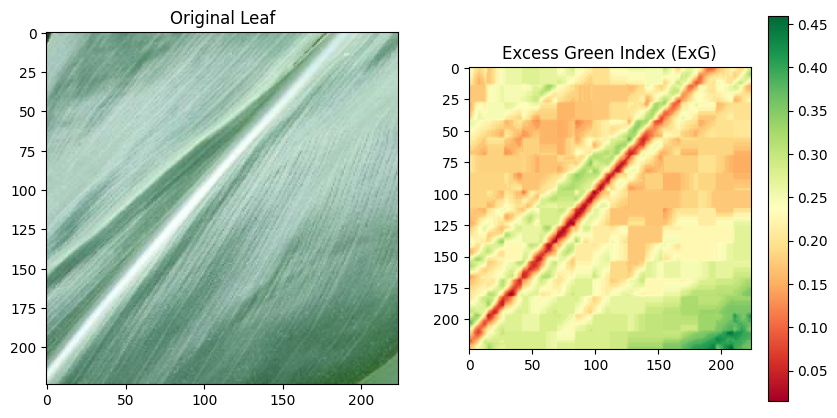

In [12]:
def calculate_exg(image):
    img = image.numpy() if hasattr(image, 'numpy') else image
    r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]

    # Formula: 2*Green - Red - Blue
    exg = 2*g - r - b
    return exg

# Visualize the feature extraction
for images, labels in training_set.take(1):
    original = images[0].numpy()
    exg_feature = calculate_exg(images[0])

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Leaf")
    plt.imshow(original)


    plt.subplot(1, 2, 2)
    plt.title("Excess Green Index (ExG)")
    plt.imshow(exg_feature, cmap='RdYlGn') # Red=Lesions, Green=Healthy
    plt.colorbar()
    plt.show()

## 2. Model Selection (Transfer Learning)

In [13]:
# 1. Base Model: Use pre-trained weights from ImageNet
base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False, # Drop the original 1000-class head
                         weights='imagenet')

# 2. Freeze the base model (don't update pre-trained weights yet)
base_model.trainable = False

# 3. Add your custom "Head" for the 38 plant classes
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2), # Prevent overfitting
    layers.Dense(38, activation='softmax') # Output for your 38 classes
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## 3. Performance Visualization

In [14]:
# Train for a few epochs to get early performance data
history = model.fit(
    training_set,
    validation_data = validation_set,
    epochs=2
)

Epoch 1/2
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 170s 68ms/step - accuracy: 0.8813 - loss: 0.3802 - val_accuracy: 0.9447 - val_loss: 0.1703
Epoch 2/2
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 145s 66ms/step - accuracy: 0.9393 - loss: 0.1788 - val_accuracy: 0.9516 - val_loss: 0.1472


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━

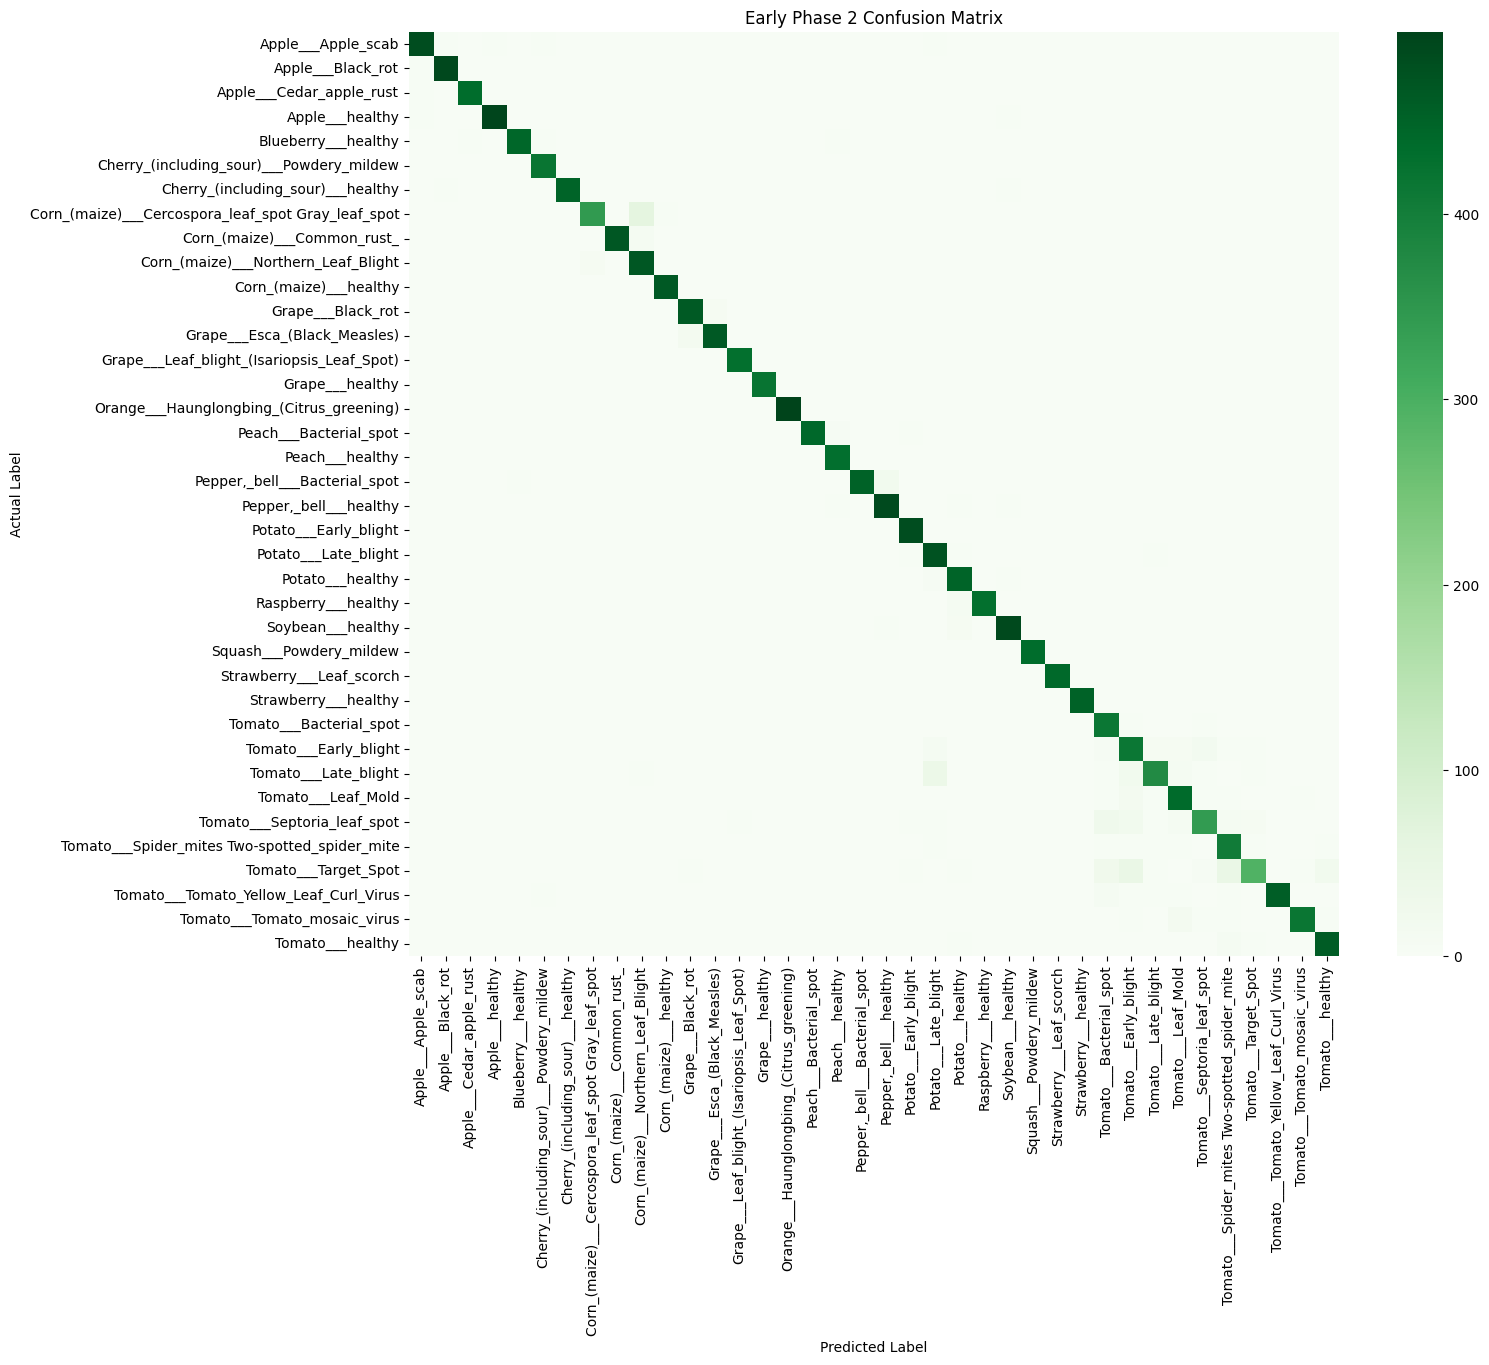

In [15]:
# 1. Collect true labels and predictions
y_true = []
y_pred = []

# Loop through the validation set
for images, labels in validation_set:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Create the Matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title("Early Phase 2 Confusion Matrix")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

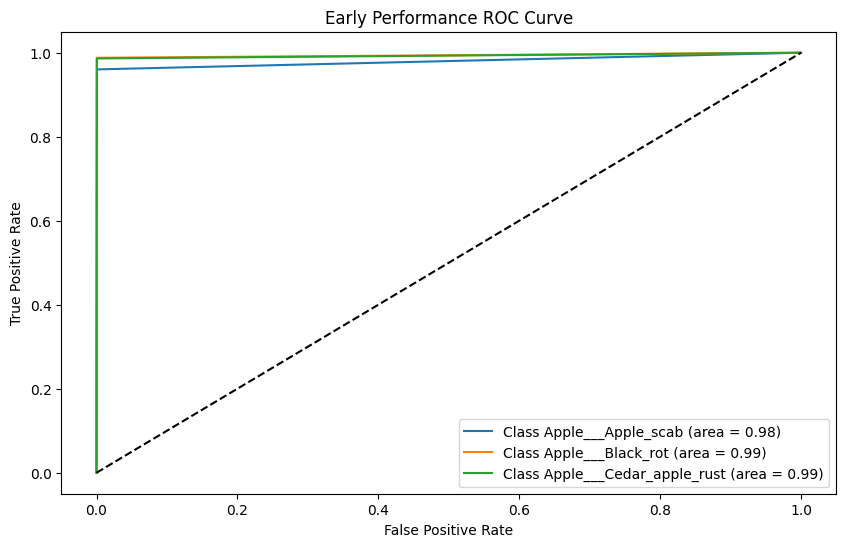

In [16]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=list(range(38)))
y_pred_bin = label_binarize(y_pred, classes=list(range(38)))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(38):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot the ROC for a few sample classes
plt.figure(figsize=(10, 6))
for i in range(3): # Plotting first 3 classes as an example
    plt.plot(fpr[i], tpr[i], label=f'Class {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Early Performance ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Using the MobileNetV2 base we established
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Keep the pre-trained weights frozen initially

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5), # Phase 3 Task: Prevent overfitting
    layers.Dense(38, activation='softmax') # Output for your 38 classes
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
# Phase 3 Task: Early Stopping & Saving the best model
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='plant_health_model_best.h5',
        save_best_only=True,
        monitor='val_accuracy'
    )
]

# Actual Training Process
history = model.fit(
    training_set,
    validation_data=validation_set, # Using your optimized subset
    epochs=10,
    callbacks=callbacks
)

plt.figure(figsize=(10, 6))

plt.plot(history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='blue', label='Validation Accuracy')


epochs = range(1, len(history.history['accuracy']) + 1)
plt.xticks(ticks=range(len(epochs)), labels=epochs)


plt.title('Visualization of Accuracy Result', fontsize=16)
plt.xlabel('No. of Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12) # Optional, aligns with the y-axis values
plt.legend(loc='lower right', fontsize=12, frameon=True, facecolor='white', edgecolor='gray')
plt.tight_layout()
plt.show()

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7222 - loss: 0.9651

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 169s 72ms/step - accuracy: 0.8240 - loss: 0.5713 - val_accuracy: 0.9309 - val_loss: 0.2077
Epoch 2/10
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8963 - loss: 0.3118

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 152s 51ms/step - accuracy: 0.9008 - loss: 0.2966 - val_accuracy: 0.9464 - val_loss: 0.1609
Epoch 3/10
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9159 - loss: 0.2484

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 128s 58ms/step - accuracy: 0.9158 - loss: 0.2502 - val_accuracy: 0.9524 - val_loss: 0.1419
Epoch 4/10
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9225 - loss: 0.2291

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 144s 59ms/step - accuracy: 0.9232 - loss: 0.2274 - val_accuracy: 0.9536 - val_loss: 0.1351
Epoch 5/10
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9292 - loss: 0.2115

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 108s 49ms/step - accuracy: 0.9299 - loss: 0.2110 - val_accuracy: 0.9565 - val_loss: 0.1296
Epoch 6/10
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9324 - loss: 0.1993

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 113s 52ms/step - accuracy: 0.9333 - loss: 0.1987 - val_accuracy: 0.9576 - val_loss: 0.1222
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 111s 50ms/step - accuracy: 0.9375 - loss: 0.1848 - val_accuracy: 0.9556 - val_loss: 0.1324
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9422 - loss: 0.1736

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 160s 59ms/step - accuracy: 0.9407 - loss: 0.1765 - val_accuracy: 0.9619 - val_loss: 0.1133
Epoch 9/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 109s 50ms/step - accuracy: 0.9416 - loss: 0.1689 - val_accuracy: 0.9596 - val_loss: 0.1208
Epoch 10/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 129s 58ms/step - accuracy: 0.9461 - loss: 0.1574 - val_accuracy: 0.9592 - val_loss: 0.1249


In [19]:
from sklearn.metrics import classification_report

# 1. Generate predictions on the test set
# Replace 'test_set' with your designated test directory loader
y_true = []
y_pred = []

for images, labels in validation_set:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Print the final metrics report
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━

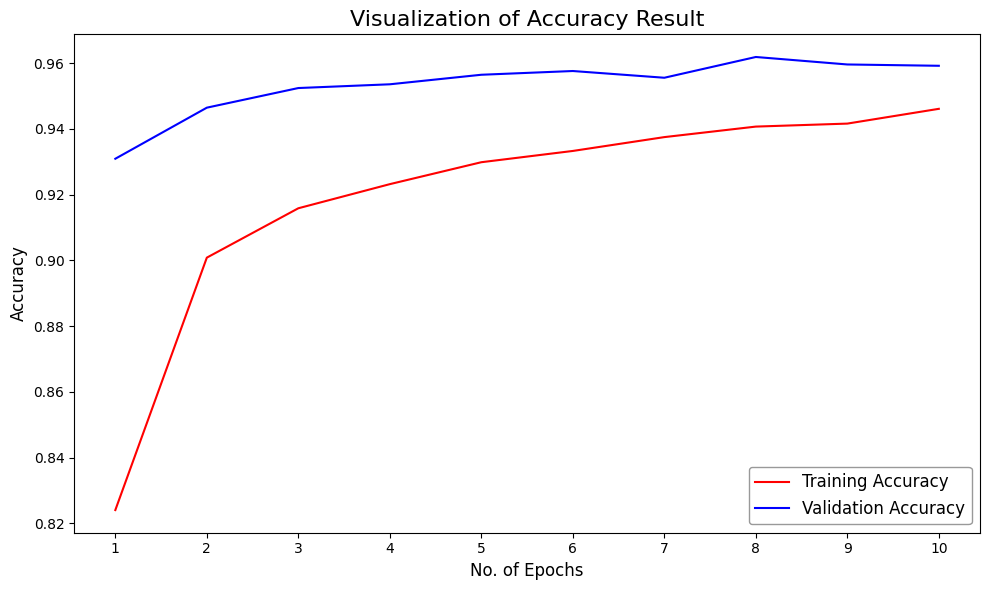

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], color='blue', label='Validation Accuracy')


epochs = range(1, len(history.history['accuracy']) + 1)
plt.xticks(ticks=range(len(epochs)), labels=epochs)


plt.title('Visualization of Accuracy Result', fontsize=16)
plt.xlabel('No. of Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12) # Optional, aligns with the y-axis values
plt.legend(loc='lower right', fontsize=12, frameon=True, facecolor='white', edgecolor='gray')

plt.tight_layout()
plt.show()